# Linear regression: from a gradient to least squares

**Objective.** Fit a multivariable linear relationship using our reusable gradient-descent
solver, then check its predictions against the direct solver and scikit-learn.
The test set measures prediction quality; agreement between solvers measures implementation correctness.

## Reproducible setup

Install the package from the repository root with `python -m pip install -e ".[dev]"`,
then select a kernel from that environment. Run all cells from top to bottom.
The algorithm is imported from `ml_from_scratch`; this notebook contains only the experiment.
All data are bundled with scikit-learn or generated locally, with seed 42.

## Mathematical intuition

For $X\in\mathbb R^{n\times d}$, predictions are $\hat y=Xw+b$ and
$$J(w,b)=\frac1n\|Xw+b-y\|_2^2.$$
With residual vector $r=Xw+b-y$, differentiating gives
$$\nabla_w J=\frac2n X^T r,\qquad \frac{\partial J}{\partial b}=\frac2n\sum_i r_i.$$
Gradient descent subtracts a small multiple of this gradient. A direct least-squares solve
minimizes the same objective using NumPy's SVD-based `lstsq`, avoiding an explicit matrix inverse.
Standardizing features improves the geometry seen by a fixed learning rate.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression as ReferenceLinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from ml_from_scratch import LinearRegression

SEED = 42
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.2})

## Dataset and leakage-free preparation

Generate 600 samples with eight features, six informative features, an intercept of 12,
and Gaussian noise with standard deviation 10. Reserve 25% for testing before calculating
means or standard deviations. Targets remain in their original units.

In [2]:
X, y = make_regression(
    n_samples=600,
    n_features=8,
    n_informative=6,
    noise=10,
    bias=12,
    random_state=SEED,
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
)
mean, scale = X_train.mean(axis=0), X_train.std(axis=0)
scale = np.where(scale > 0, scale, 1.0)
X_train, X_test = (X_train - mean) / scale, (X_test - mean) / scale
print(f"Training: {X_train.shape}; held out: {X_test.shape}")

Training: (450, 8); held out: (150, 8)


## Fit both package solvers

The `gd` solver exposes its objective history and convergence status. The `normal` name
denotes a direct least-squares solution; the implementation does not invert normal equations.
Learned coefficients have shape `(n_features,)`, and predictions have one value per sample.

In [3]:
gd = LinearRegression(solver="gd", learning_rate=0.1, max_iter=5000, tol=1e-7).fit(X_train, y_train)
direct = LinearRegression(solver="normal").fit(X_train, y_train)
print(f"GD converged: {gd.converged_}; updates: {gd.n_iter_}")
print(f"Coefficient shape: {gd.coef_.shape}; intercept: {gd.intercept_:.3f}")

GD converged: True; updates: 111
Coefficient shape: (8,); intercept: 8.023


## Independent reference and held-out results

Both estimators receive exactly the same matrices. Metrics below come from scikit-learn
and are applied independently to all predictions. A nonzero test MSE is expected because
the targets contain noise, even when the implementations agree almost perfectly.

In [4]:
reference = ReferenceLinearRegression().fit(X_train, y_train)
for name, model in [("NumPy GD", gd), ("NumPy direct", direct), ("scikit-learn", reference)]:
    prediction = model.predict(X_test)
    print(
        f"{name:14s} MSE={mean_squared_error(y_test, prediction):.6f}  "
        f"R2={r2_score(y_test, prediction):.6f}"
    )
prediction_gap = np.sqrt(mean_squared_error(reference.predict(X_test), gd.predict(X_test)))
print(f"GD / reference prediction RMSE: {prediction_gap:.3e}")

NumPy GD       MSE=93.242032  R2=0.993494
NumPy direct   MSE=93.242032  R2=0.993494
scikit-learn   MSE=93.242032  R2=0.993494
GD / reference prediction RMSE: 5.492e-08


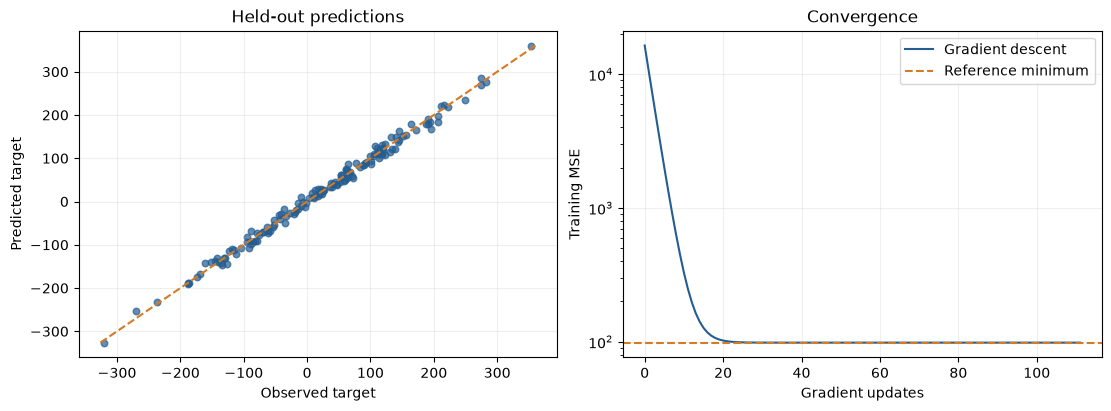

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
prediction = gd.predict(X_test)
axes[0].scatter(y_test, prediction, color="#245d91", s=22, alpha=0.7)
bounds = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(bounds, bounds, "--", color="#d57a25")
axes[0].set(xlabel="Observed target", ylabel="Predicted target", title="Held-out predictions")
axes[1].semilogy(gd.loss_history_, color="#245d91", label="Gradient descent")
axes[1].axhline(
    mean_squared_error(y_train, reference.predict(X_train)),
    color="#d57a25",
    linestyle="--",
    label="Reference minimum",
)
axes[1].set(xlabel="Gradient updates", ylabel="Training MSE", title="Convergence")
axes[1].legend()
plt.show()

## Conclusion

The printed prediction gap tests whether iterative optimization reaches the same solution
as direct least squares. The loss curve explains how it gets there; test MSE answers a
separate predictive question. On poorly conditioned data, fixed-step GD can need many more
updates. Inspect `converged_` before treating the last iterate as an optimum.

The automated suite repeats this comparison on diabetes and records settings, iteration
counts, timings, and the full numerical differences. See
[the derivation](../docs/mathematics.md) and [benchmark methodology](../docs/benchmarking.md).